# 01 L1B Structure and Refh

Purpose:
- inspect root attributes, dimensions, and key datasets,
- explain pulse, track, sweep, refh, and `rx_waveform`,
- check whether `sweep_num` and `track_num` form a complete grid,
- visualize refh footprint plus SNR, amplitude, and refh distributions.

Scientific notes:
- CASALS L1B is treated here as a geolocated waveform product.
- Each pulse has one official geolocated `refh` point.
- `refh` corresponds to the Rx waveform maximum-amplitude bin.
- `refh` is not an official multi-return point cloud.

In [1]:
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt

H5_PATH = Path('../casals_h5_downloads/casals_l1b_20241112T165718_001_02.h5')
assert H5_PATH.exists(), H5_PATH

In [2]:
with h5py.File(H5_PATH, 'r') as h5:
    attrs = {k: (v.decode('utf-8', 'replace') if isinstance(v, bytes) else v.tolist() if hasattr(v, 'tolist') else v) for k, v in h5.attrs.items()}
    keys = sorted(h5.keys())
    refh_lon = h5['refh_longitude'][:]
    refh_lat = h5['refh_latitude'][:]
    refh = h5['refh'][:]
    refh_amp = h5['refh_amp'][:]
    refh_snr = h5['refh_snr'][:]
    good_snr = h5['good_snr'][:].astype(bool)
    sweep_num = h5['sweep_num'][:]
    track_num = h5['track_num'][:]
    rx_shape = h5['rx_waveform'].shape if 'rx_waveform' in h5 else None

print('root keys:', keys)
print('selected attrs:', {k: attrs.get(k) for k in ['start_utca', 'end_utca', 'n_pulses', 'n_sweeps', 'n_tracks', 'n_rx_bins']})
print('rx_waveform shape:', rx_shape)

root keys: ['bg_mean', 'bg_std', 'bin_size', 'dac', 'delta_time', 'geoid', 'geoid_free2mean', 'good_snr', 'instrument_altitude', 'instrument_altitude_error', 'instrument_latitude', 'instrument_latitude_error', 'instrument_longitude', 'instrument_longitude_error', 'local_beam_azimuth', 'local_beam_azimuth_error', 'local_beam_elevation', 'local_beam_elevation_error', 'range_bias_correction', 'refh', 'refh_amp', 'refh_bounce_time_offset', 'refh_bounce_time_offset_error', 'refh_error', 'refh_latitude', 'refh_latitude_error', 'refh_longitude', 'refh_longitude_error', 'refh_neutat_delay_derivative', 'refh_neutat_delay_total', 'refh_snr', 'refh_thres', 'rwstart', 'rwstart_bounce_time_offset', 'rwstart_bounce_time_offset_error', 'rwstart_error', 'rwstart_latitude', 'rwstart_latitude_error', 'rwstart_longitude', 'rwstart_longitude_error', 'rwstart_neutat_delay_derivative', 'rwstart_neutat_delay_total', 'rwstop', 'rwstop_bounce_time_offset', 'rwstop_bounce_time_offset_error', 'rwstop_error', 'rw

In [3]:
n_sweeps = int(np.nanmax(sweep_num)) + 1
n_tracks = int(np.nanmax(track_num)) + 1
flat = sweep_num.astype(np.int64) * n_tracks + track_num.astype(np.int64)
counts = np.bincount(flat, minlength=n_sweeps * n_tracks)
print('n_records:', refh_lon.size)
print('n_sweeps:', n_sweeps)
print('n_tracks:', n_tracks)
print('duplicate cells:', int(np.sum(counts > 1)))
print('missing cells:', int(np.sum(counts == 0)))

n_records: 3604480
n_sweeps: 14080
n_tracks: 256
duplicate cells: 0
missing cells: 0


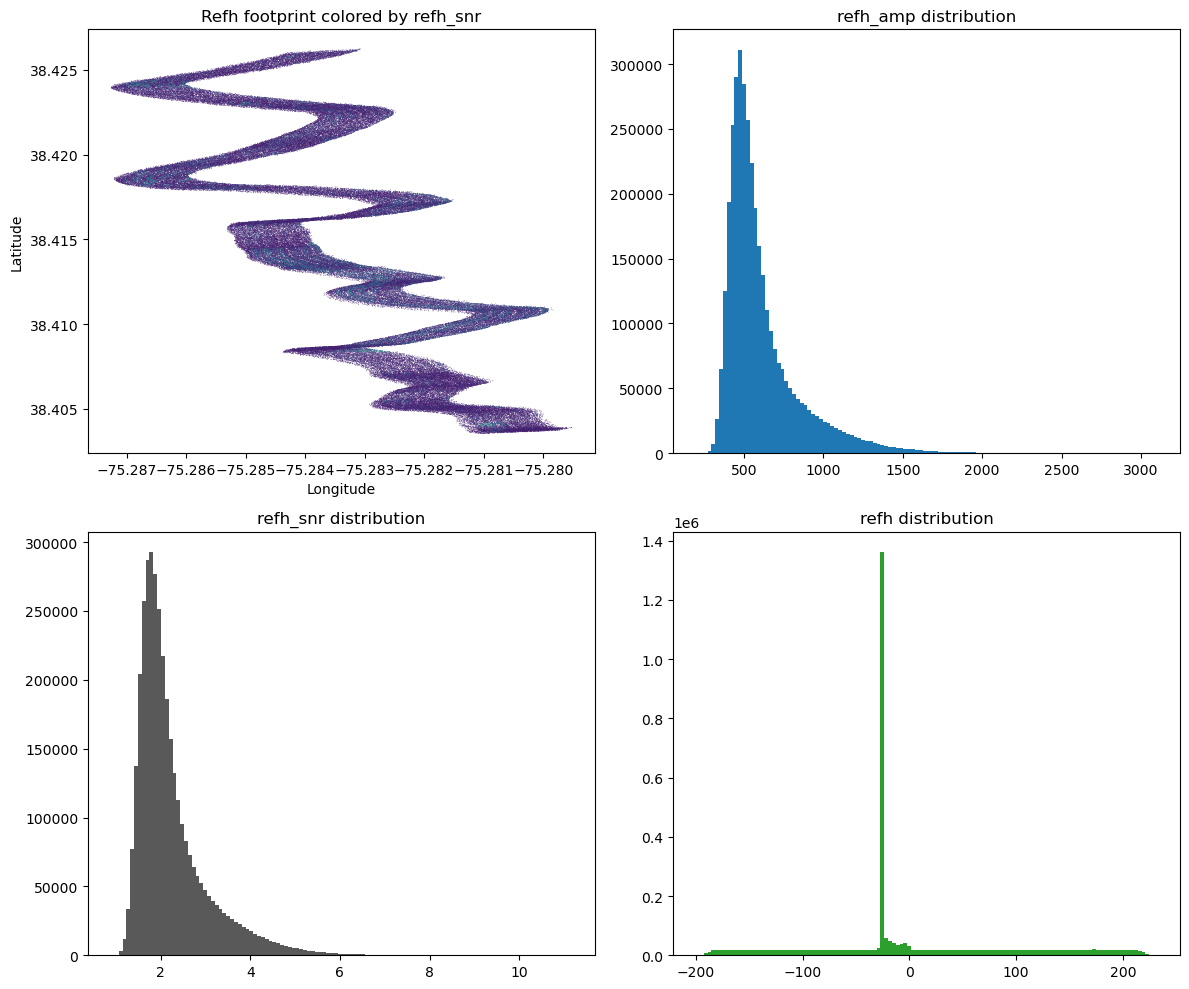

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sample = np.random.default_rng(42).choice(refh_lon.size, size=min(200_000, refh_lon.size), replace=False)
axes[0, 0].scatter(refh_lon[sample], refh_lat[sample], c=refh_snr[sample], s=0.2, cmap='viridis', linewidths=0)
axes[0, 0].set_title('Refh footprint colored by refh_snr')
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')
axes[1, 0].hist(refh_snr[np.isfinite(refh_snr)], bins=120, color='0.35')
axes[1, 0].set_title('refh_snr distribution')
axes[0, 1].hist(refh_amp[np.isfinite(refh_amp)], bins=120, color='tab:blue')
axes[0, 1].set_title('refh_amp distribution')
axes[1, 1].hist(refh[np.isfinite(refh)], bins=120, color='tab:green')
axes[1, 1].set_title('refh distribution')
fig.tight_layout()